# Reading Copernicus GlobColour Chlorophyll data

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [3]:
# read in the data
input_path = '../../../Data/GlobColour/cmems_obs-oc_glo_bgc-plankton_my_l4-olci-4km_P1M.nc'
ds = xr.open_dataset(input_path)

In [3]:
ds

<xarray.Dataset> Size: 11MB
Dimensions:          (time: 66, latitude: 120, longitude: 120)
Coordinates:
  * latitude         (latitude) float32 480B -2.979 -2.938 ... 1.938 1.979
  * longitude        (longitude) float32 480B -92.98 -92.94 ... -88.06 -88.02
  * time             (time) datetime64[ns] 528B 2019-01-01 ... 2024-06-01
Data variables:
    CHL              (time, latitude, longitude) float32 4MB ...
    CHL_uncertainty  (time, latitude, longitude) float32 4MB ...
    flags            (time, latitude, longitude) float32 4MB ...
Attributes:
    Conventions:       CF-1.11
    title:             cmems_obs-oc_glo_bgc-plankton_my_l4-olci-4km_P1M
    institution:       ACRI
    source:            surface observation
    history:           Created using software developed at ACRI-ST
    contact:           servicedesk.cmems@acri-st.fr
    references:        http://www.globcolour.info GlobColour has been origina...
    comment:           average
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  OCEANCOLOUR_GLO_BGC_L4_MY_009_104
    subset:datasetId:  cmems_obs-oc_glo_bgc-plankton_my_l4-olci-4km_P1M_202207
    subset:date:       2024-07-10T00:39:20.982Z

In [4]:
mean_chl = ds.CHL.mean(dim=['latitude','longitude'])
mean_chl

<xarray.DataArray 'CHL' (time: 66)> Size: 264B
array([0.24681756, 0.3345479 , 0.31344387, 0.23456576, 0.300873  ,
       0.30566904, 0.35651597, 0.41397715, 0.31796473, 0.29041773,
       0.22661497, 0.23067544, 0.2784563 , 0.2475022 , 0.3593818 ,
       0.21139847, 0.39193714, 0.400123  , 0.39474696, 0.34143692,
       0.4977736 , 0.5683026 , 0.2916064 , 0.41380754, 0.3147308 ,
       0.24965604, 0.33900845, 0.24898273, 0.22997846, 0.26120526,
       0.2744591 , 0.42128393, 0.4960307 , 0.2670676 , 0.31205264,
       0.3233112 , 0.32406804, 0.30547172, 0.21791533, 0.33012366,
       0.28380314, 0.26156846, 0.24464993, 0.21210933, 0.58848244,
       0.40215385, 0.27121338, 0.3496016 , 0.35907328, 0.28756666,
       0.25363335, 0.21608101, 0.23359138, 0.21333149, 0.22863775,
       0.28604978, 0.2901365 , 0.32256514, 0.18484168, 0.18089144,
       0.20609853, 0.26084495, 0.29805315, 0.23193988, 0.28039616,
       0.27968696], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 528B 2019-01-01 2019-02-01 ... 2024-06-01

In [6]:
# select only the area of the islands
# and data from 1980 until 2023
# galapagos = ds.sst.sel(latitude=slice(2,-2), longitude=slice(-92,-88), time=slice('1980','2023'))
# galapagos

In [13]:
x_nh = np.arange(1, len(mean_chl.time)+1)
y_nh = mean_chl.values

x_nh, y_nh

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66]),
 array([0.24681756, 0.3345479 , 0.31344387, 0.23456576, 0.300873  ,
        0.30566904, 0.35651597, 0.41397715, 0.31796473, 0.29041773,
        0.22661497, 0.23067544, 0.2784563 , 0.2475022 , 0.3593818 ,
        0.21139847, 0.39193714, 0.400123  , 0.39474696, 0.34143692,
        0.4977736 , 0.5683026 , 0.2916064 , 0.41380754, 0.3147308 ,
        0.24965604, 0.33900845, 0.24898273, 0.22997846, 0.26120526,
        0.2744591 , 0.42128393, 0.4960307 , 0.2670676 , 0.31205264,
        0.3233112 , 0.32406804, 0.30547172, 0.21791533, 0.33012366,
        0.28380314, 0.26156846, 0.24464993, 0.21210933, 0.58848244,
        0.40215385, 0.27121338, 0.3496016 , 0.35907328, 0.28756666,
        0.25363335, 0.

In [17]:
# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],4)
slope_nh_sd = np.round(np.sqrt(V[0][0]),4)

<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_11712/1930580346.py:9: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel("Chl-a ($mg \ m^{-3}$)")


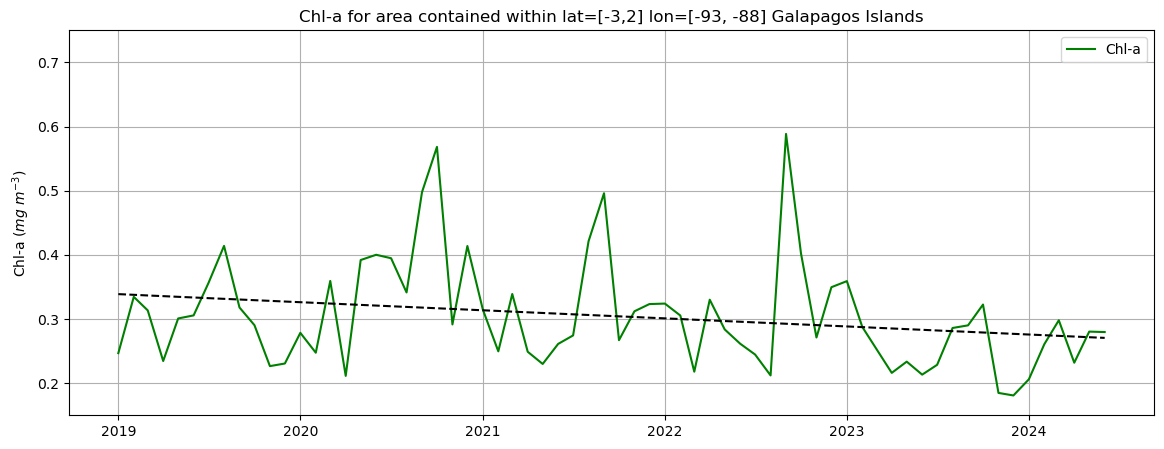

In [19]:



plt.figure(figsize=(14,5))
plt.plot(mean_chl.time, mean_chl, color="g", label="Chl-a")

plt.plot(mean_chl.time[x_nh-1], poly_nh(x_nh), linestyle="dashed", color='k')#, 
         #label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd))

plt.title("Chl-a for area contained within lat=[-3,2] lon=[-93, -88] Galapagos Islands")
plt.ylim(0.15,0.75)
plt.ylabel("Chl-a ($mg \ m^{-3}$)")
plt.legend()
plt.grid()